Experiment No.: 2

Name: Rakesh Santosh Yadav

Roll No.: 4012

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, losses
import matplotlib.pyplot as plt

In [6]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
latent_dim = 10
input_dim = 784

In [8]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, latent_dim):
    super(Encoder, self).__init__()
    self.dense1 = layers.Dense(512, activation="relu")
    self.dense_mean = layers.Dense(latent_dim)
    self.dense_log_var = layers.Dense(latent_dim)
  def call(self, inputs):
    x = self.dense1(inputs)
    z_mean = self.dense_mean(x)
    z_log_var = self.dense_log_var(x)
    return z_mean, z_log_var

In [9]:
class Sampling(tf.keras.layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [10]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, original_dim):
    super(Decoder, self).__init__()
    self.dense1 = layers.Dense(512, activation="relu")
    self.dense_output = layers.Dense(original_dim,activation="sigmoid")
  def call(self, inputs):
    x = self.dense1(inputs)
    return self.dense_output(x)

In [11]:
class VAE(tf.keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    self.sampler = Sampling()
  def call(self, inputs):
    z_mean, z_log_var = self.encoder(inputs)
    z = self.sampler((z_mean, z_log_var))
    reconstructed = self.decoder(z)
    kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    self.add_loss(tf.reduce_mean(kl_loss))
    return reconstructed

In [12]:
encoder = Encoder(latent_dim)
decoder = Decoder(input_dim)
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [13]:
# Train
vae.fit(x_train, x_train,epochs=50,batch_size=128,validation_data=(x_test, x_test))
# Reconstruct images
decoded_imgs = vae.predict(x_test[:10])

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - loss: 0.1455 - val_loss: 0.0682
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0679 - val_loss: 0.0679
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0677 - val_loss: 0.0677
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0675 - val_loss: 0.0677
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0675 - val_loss: 0.0676
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 0.0674 - val_loss: 0.0676
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0674 - val_loss: 0.0676
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0675 - val_loss: 0.0676
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0674 - val_loss: 0.0676
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 12/50
469/469 ━━━━━━━━━━

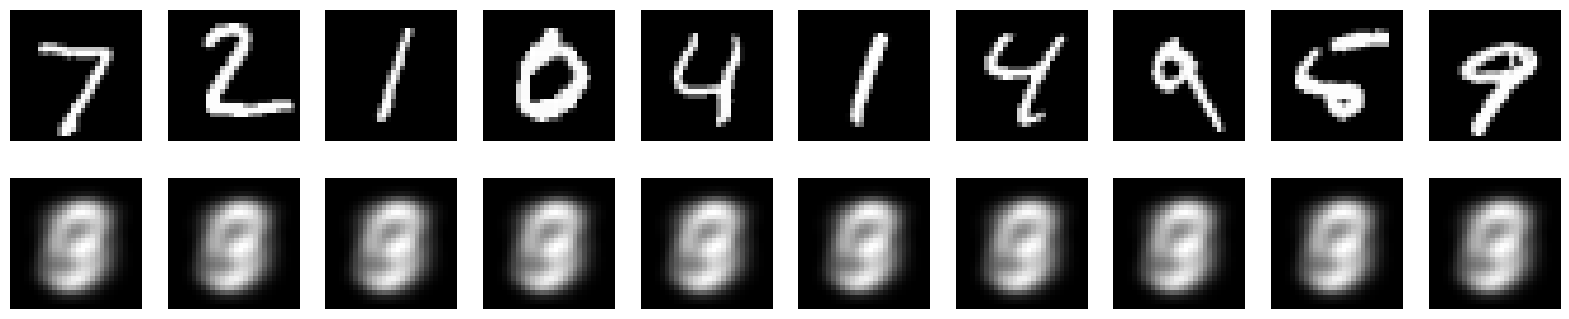

In [14]:
plt.figure(figsize=(20, 4))
for i in range(10):
  # Original
  ax = plt.subplot(2, 10, i + 1)
  plt.imshow(x_test[i].reshape(28, 28))
  plt.gray()
  ax.axis('off')
  # Reconstructed
  ax = plt.subplot(2, 10, i + 1 + 10)
  plt.imshow(decoded_imgs[i].reshape(28, 28))
  plt.gray()
  ax.axis('off')
plt.show()